Loaded delta-0.1-45.out: angle=45.0°, Fx=1.777e+01, Fy=1.777e+01, components=x,y, n_points=101
maximum displacement (x): 0.07988
sigma_noise added (x): 0.001598 (2.0% of maximum displacement)
realized experimental noise (x): 0.001419
maximum displacement (y): 0.01679
sigma_noise added (y): 0.0003359 (2.0% of maximum displacement)
realized experimental noise (y): 0.0003219
sigma_noise prior: Exp(beta=126.6)
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise_x.pdf


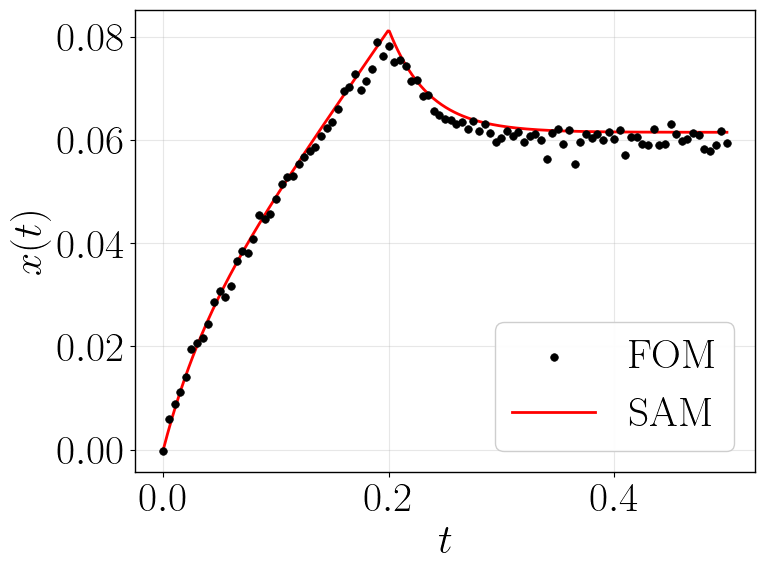

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise_y.pdf


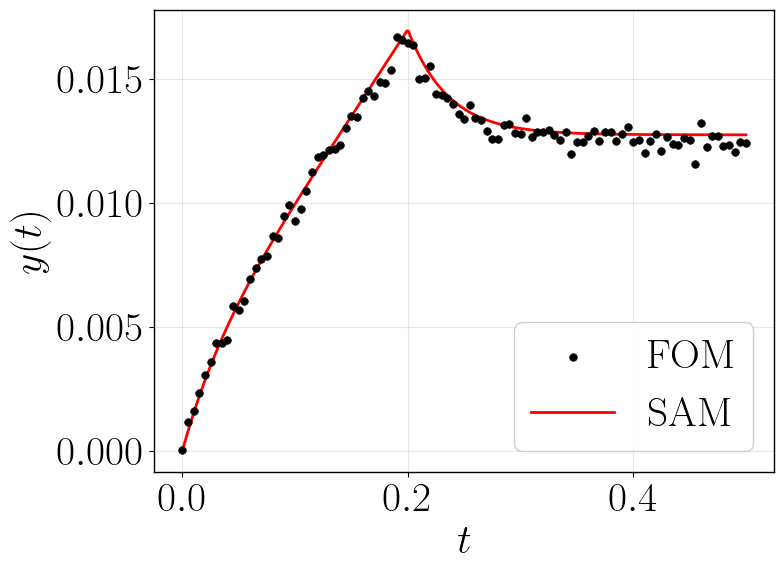

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\prior.pdf


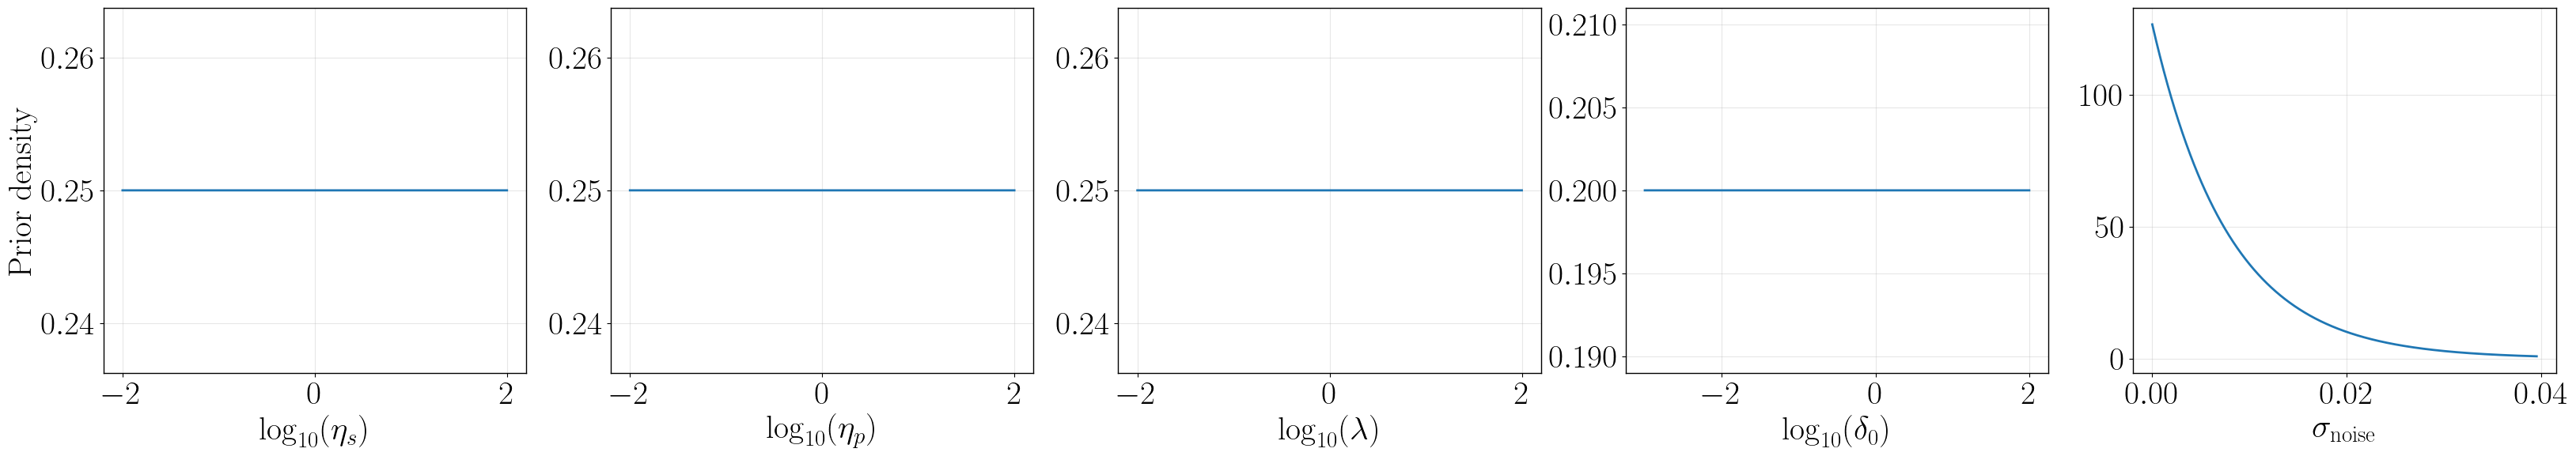


Preparing MCMC: ndim=5, walkers=10, steps=5000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [6.15845988e+00 1.95454851e+01 3.73666776e+01 7.11702564e-02
 5.76956298e-04]
  01: [1.39398218e+01 1.79998557e-02 1.49697678e-02 2.39069752e-01
 2.21251210e-03]
  02: [5.69526267e-01 5.09401190e+01 2.61880929e-01 6.87936990e+01
 1.09884416e-02]
  03: [6.33204149e-01 3.36246364e+00 5.39753930e+00 2.23393212e+00
 1.30938708e-03]
  04: [2.38072587e-02 5.93822700e-01 1.29877520e+01 2.22730174e-01
 8.95963562e-03]
  05: [3.25427710e-02 2.04420614e+01 4.14150289e-02 1.36315972e-02
 2.53553807e-03]
  06: [7.98894455e+01 8.10876823e-02 6.00557827e-02 8.85843077e-03
 1.06998700e-02]
  07: [1.10804860e+01 1.65325235e+00 7.36010508e-01 4.46280105e-03
 8.86461027e-03]
  08: [1.24687867e+01 3.04223037e-01 1.07733547e+01 5.29432722e+00
 1.05368399e-02]
  09: [2.71889026e+01 3.76236114e+00 7.63470213e+01 4.25722683e-02
 8.56473534e-03]

Warm-up: 500 steps x 10 walkers


 11%|█         | 529/5000 [00:40<10:06,  7.37it/s]

In [ ]:
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import InferenceProcedure

model = InferenceProcedure(
    force=8*np.pi,
    material_model="viscoelastic",
    boundary_model="bounded",
    theta=45,
    delta0 = 0.1,
    sigma_noise_percent=2.0,
    nsteps =5000,
    use_y = True,
    thin_factor = 2,
    sigma_bias = None)

model.load_data("data/linear_viscoelastic/angle45/delta-0.1-45.out")

model.plot_data(theta_true=[0.5, 0.9, 0.1, 0.1]) #  [eta_s, eta_p, lambda, delta_0]
model.plot_prior()
model.run_mcmc(init_method="kmeans", warmup = True)
model.plot_results()